# ROI Population Density Review And Hotspot Clustering

This notebook loads one extracted UCDB ROI raster, applies a saturation-sensitive transform so near-`1.0` values are easier to distinguish, and builds hotspot clusters with scikit-learn.

The default example is **Tokyo**, but you can switch to any ROI listed in `data/outputs/roi/roi_manifest.json` by changing the parameter cell below.

In [45]:
import json
import os
import warnings
from pathlib import Path

os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib')

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
import seaborn as sns
from IPython.display import display
from matplotlib import colors
from matplotlib.lines import Line2D
from rasterio.transform import xy
from sklearn.cluster import MiniBatchKMeans
from sklearn.preprocessing import StandardScaler

sns.set_theme(style='whitegrid', context='talk')
warnings.filterwarnings('ignore', category=FutureWarning)
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 120)

print('Seaborn version:', sns.__version__)

Seaborn version: 0.13.2


## Parameters

- `SELECTED_CITY` must match `matched_name` in the ROI manifest.
- `HOTSPOT_QUANTILE` controls candidate hotspot selection on the **local saturation score**, not the raw baseline.
- `N_CLUSTERS` is intentionally much larger than before so dense metros are partitioned into many hotspot groups instead of a few oversized blobs.

In [78]:
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'data').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

ROI_DIR = PROJECT_ROOT / 'data/outputs/roi'
MANIFEST_PATH = ROI_DIR / 'roi_manifest.json'
VECTOR_PATH = ROI_DIR / 'ucdb_rois_buffer10km.gpkg'

SELECTED_CITY = 'New Delhi'
HOTSPOT_QUANTILE = 0.5
N_CLUSTERS = 1000
RANDOM_STATE = 42
SATURATION_EPS = 1e-6

In [79]:
def load_manifest(manifest_path: Path) -> dict:
    return json.loads(manifest_path.read_text())


def find_roi_record(manifest: dict, city_name: str) -> dict:
    for record in manifest['rois']:
        if record['matched_name'] == city_name:
            return record
    raise KeyError(f'City not found in manifest: {city_name}')


def load_roi(record: dict):
    baseline_path = PROJECT_ROOT / Path(record['baseline_path'])
    mask_path = PROJECT_ROOT / Path(record['mask_path'])
    with rasterio.open(baseline_path) as src:
        baseline = src.read(1).astype(np.float32)
        transform = src.transform
        crs = src.crs
        nodata = src.nodata
    with rasterio.open(mask_path) as src:
        roi_mask = src.read(1).astype(np.uint8)
    valid = (baseline != nodata) & (roi_mask == 1)
    return baseline, roi_mask, valid, transform, crs, nodata, baseline_path, mask_path


def percentile_rank_map(values: np.ndarray, valid_mask: np.ndarray) -> np.ndarray:
    ranked = np.full(values.shape, np.nan, dtype=np.float32)
    valid_values = values[valid_mask]
    pct = pd.Series(valid_values).rank(method='average', pct=True).to_numpy(dtype=np.float32)
    ranked[valid_mask] = pct
    return ranked


def local_mean_3x3(values: np.ndarray, valid_mask: np.ndarray) -> np.ndarray:
    filled = np.where(valid_mask, values, 0.0).astype(np.float32)
    valid_float = valid_mask.astype(np.float32)
    h, w = values.shape
    sum_arr = np.zeros((h, w), dtype=np.float32)
    count_arr = np.zeros((h, w), dtype=np.float32)
    padded_values = np.pad(filled, 1, mode='constant')
    padded_valid = np.pad(valid_float, 1, mode='constant')
    for dy in range(3):
        for dx in range(3):
            sum_arr += padded_values[dy:dy + h, dx:dx + w]
            count_arr += padded_valid[dy:dy + h, dx:dx + w]
    local_mean = np.divide(sum_arr, count_arr, out=np.zeros_like(sum_arr), where=count_arr > 0)
    local_mean[~valid_mask] = np.nan
    return local_mean


def saturation_score_map(values: np.ndarray, valid_mask: np.ndarray, eps: float = 1e-6) -> np.ndarray:
    score = np.full(values.shape, np.nan, dtype=np.float32)
    score[valid_mask] = -np.log10(np.maximum(1.0 - values[valid_mask], eps))
    return score


def robust_limits(valid_values: np.ndarray, lower: float = 0.02, upper: float = 0.98) -> tuple[float, float]:
    lo, hi = np.quantile(valid_values, [lower, upper])
    if np.isclose(lo, hi):
        lo, hi = float(valid_values.min()), float(valid_values.max())
    return float(lo), float(hi)


def draw_heatmap(ax, values: np.ndarray, valid_mask: np.ndarray, cmap, title: str, vmin=None, vmax=None, cbar_label: str | None = None):
    heat = sns.heatmap(
        values,
        mask=~valid_mask,
        cmap=cmap,
        ax=ax,
        cbar=True,
        vmin=vmin,
        vmax=vmax,
        xticklabels=False,
        yticklabels=False,
        square=False,
    )
    ax.set_title(title)
    ax.set_xlabel('')
    ax.set_ylabel('')
    if cbar_label:
        heat.collections[0].colorbar.set_label(cbar_label)
    return heat


def build_hotspot_clusters(score_map: np.ndarray, valid_mask: np.ndarray, transform, quantile: float, n_clusters: int, random_state: int = 42):
    local_score = local_mean_3x3(score_map, valid_mask)
    local_valid = local_score[valid_mask]
    threshold = float(np.quantile(local_valid, quantile))
    candidate_mask = valid_mask & (local_score >= threshold)

    candidate_rows, candidate_cols = np.where(candidate_mask)
    candidate_count = len(candidate_rows)
    if candidate_count == 0:
        raise ValueError('No hotspot candidates found. Lower HOTSPOT_QUANTILE and rerun.')

    cluster_count = max(1, min(n_clusters, candidate_count))
    features = np.column_stack([
        candidate_cols.astype(np.float32),
        candidate_rows.astype(np.float32),
        score_map[candidate_mask].astype(np.float32),
        local_score[candidate_mask].astype(np.float32),
    ])
    scaled = StandardScaler().fit_transform(features)
    weights = np.clip(local_score[candidate_mask].astype(np.float32), 1.0, None)
    model = MiniBatchKMeans(
        n_clusters=cluster_count,
        random_state=random_state,
        n_init='auto',
        batch_size=1024,
    )
    labels = model.fit_predict(scaled, sample_weight=weights)

    cluster_grid = np.full(score_map.shape, -1, dtype=np.int16)
    cluster_grid[candidate_mask] = labels.astype(np.int16)

    xs, ys = xy(transform, candidate_rows, candidate_cols, offset='center')
    cluster_frame = pd.DataFrame({
        'cluster_id': labels,
        'row': candidate_rows,
        'col': candidate_cols,
        'x': np.asarray(xs, dtype=np.float64),
        'y': np.asarray(ys, dtype=np.float64),
        'score': score_map[candidate_mask],
        'local_score': local_score[candidate_mask],
    })

    summary = (
        cluster_frame.groupby('cluster_id', as_index=False)
        .agg(
            pixel_count=('cluster_id', 'size'),
            mean_score=('score', 'mean'),
            max_score=('score', 'max'),
            mean_local_score=('local_score', 'mean'),
            center_row=('row', 'mean'),
            center_col=('col', 'mean'),
            center_x=('x', 'mean'),
            center_y=('y', 'mean'),
        )
        .sort_values(['mean_local_score', 'pixel_count'], ascending=[False, False])
        .reset_index(drop=True)
    )

    return {
        'local_score': local_score,
        'candidate_mask': candidate_mask,
        'threshold': threshold,
        'cluster_grid': cluster_grid,
        'cluster_frame': cluster_frame,
        'summary': summary,
    }

In [80]:
manifest = load_manifest(MANIFEST_PATH)
record = find_roi_record(manifest, SELECTED_CITY)
baseline, roi_mask, valid_mask, transform, crs, nodata, baseline_path, mask_path = load_roi(record)
valid_values = baseline[valid_mask]
score_map = saturation_score_map(baseline, valid_mask, eps=SATURATION_EPS)
score_values = score_map[valid_mask]
score_rank_map = percentile_rank_map(score_map, valid_mask)
local_score = local_mean_3x3(score_map, valid_mask)
roi_gdf = gpd.read_file(VECTOR_PATH, layer='ucdb_rois', engine='pyogrio')
roi_gdf = roi_gdf[roi_gdf['matched_name'] == SELECTED_CITY].copy()

roi_summary = pd.DataFrame([
    {
        'selected_city': SELECTED_CITY,
        'baseline_file': baseline_path.name,
        'mask_file': mask_path.name,
        'shape': f'{baseline.shape[0]} x {baseline.shape[1]}',
        'valid_pixels': int(valid_mask.sum()),
        'baseline_mean': float(valid_values.mean()),
        'baseline_p50': float(np.quantile(valid_values, 0.50)),
        'baseline_p95': float(np.quantile(valid_values, 0.95)),
        'score_mean': float(score_values.mean()),
        'score_p50': float(np.quantile(score_values, 0.50)),
        'score_p95': float(np.quantile(score_values, 0.95)),
        'score_max': float(score_values.max()),
        'crs': str(crs),
    }
])
display(roi_summary)
roi_gdf[['requested_name', 'matched_name', 'country', 'area_km2', 'population_total', 'buffer_km']]

,selected_city,baseline_file,mask_file,shape,valid_pixels,baseline_mean,baseline_p50,baseline_p95,score_mean,score_p50,score_p95,score_max,crs
0,New Delhi,02_new_delhi_ucdb_buffer10km_baseline.tif,02_new_delhi_ucdb_buffer10km_mask.tif,91 x 99,5772,0.878737,0.908349,1.0,2.484864,1.037861,6.0,6.0,ESRI:54009


,requested_name,matched_name,country,area_km2,population_total,buffer_km
1,New Delhi,New Delhi,India,2139,31422507.92,10


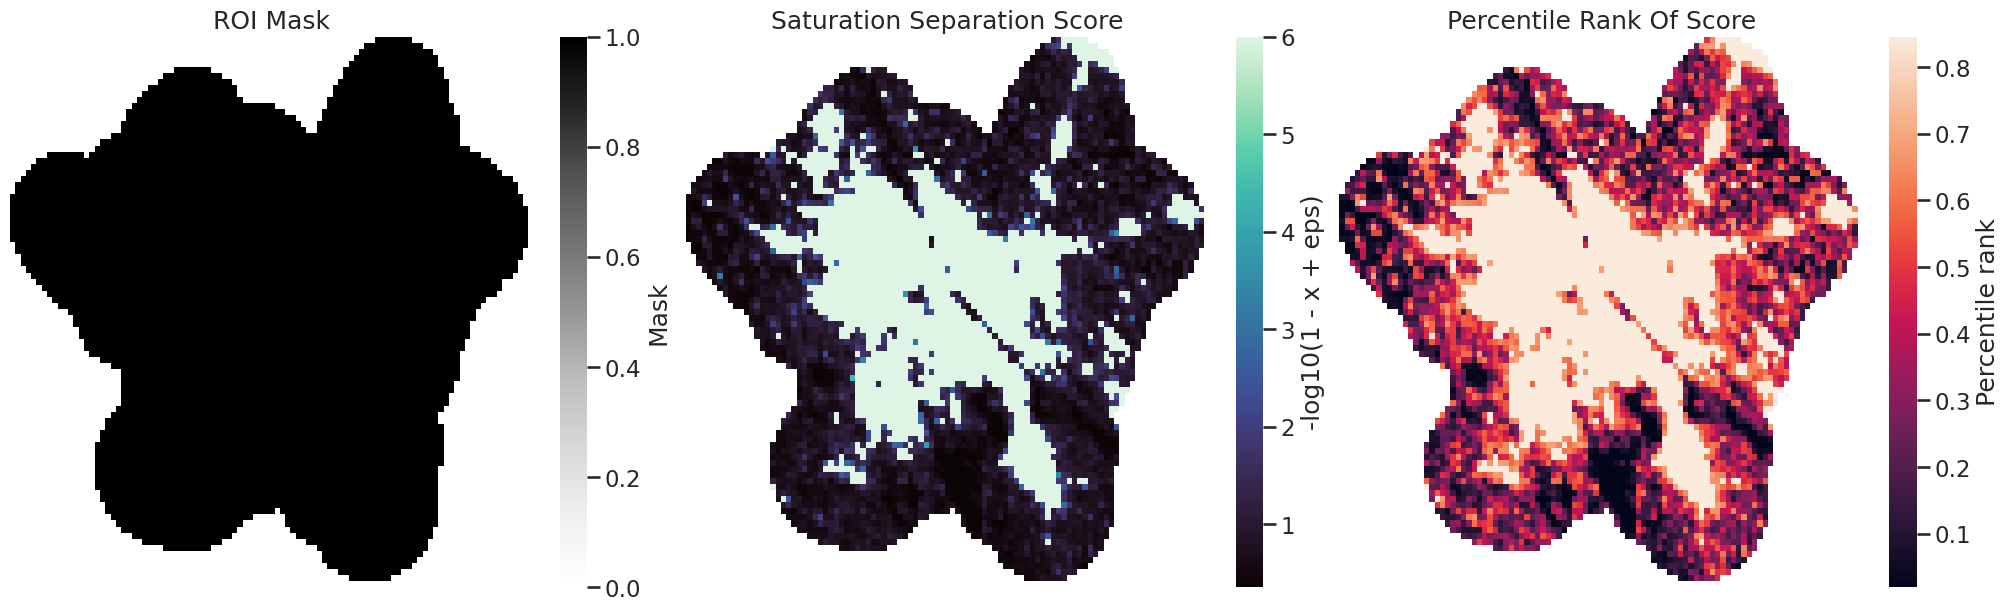

In [81]:
score_lo, score_hi = robust_limits(score_values, 0.02, 0.98)
rank_lo, rank_hi = robust_limits(score_rank_map[valid_mask], 0.02, 0.98)

fig, axes = plt.subplots(1, 3, figsize=(20, 6), constrained_layout=True)
draw_heatmap(axes[0], roi_mask.astype(float), roi_mask == 1, sns.color_palette('Greys', as_cmap=True), 'ROI Mask', vmin=0, vmax=1, cbar_label='Mask')
draw_heatmap(axes[1], score_map, valid_mask, sns.color_palette('mako', as_cmap=True), 'Saturation Separation Score', vmin=score_lo, vmax=score_hi, cbar_label='-log10(1 - x + eps)')
draw_heatmap(axes[2], score_rank_map, valid_mask, sns.color_palette('rocket', as_cmap=True), 'Percentile Rank Of Score', vmin=rank_lo, vmax=rank_hi, cbar_label='Percentile rank')
plt.show()

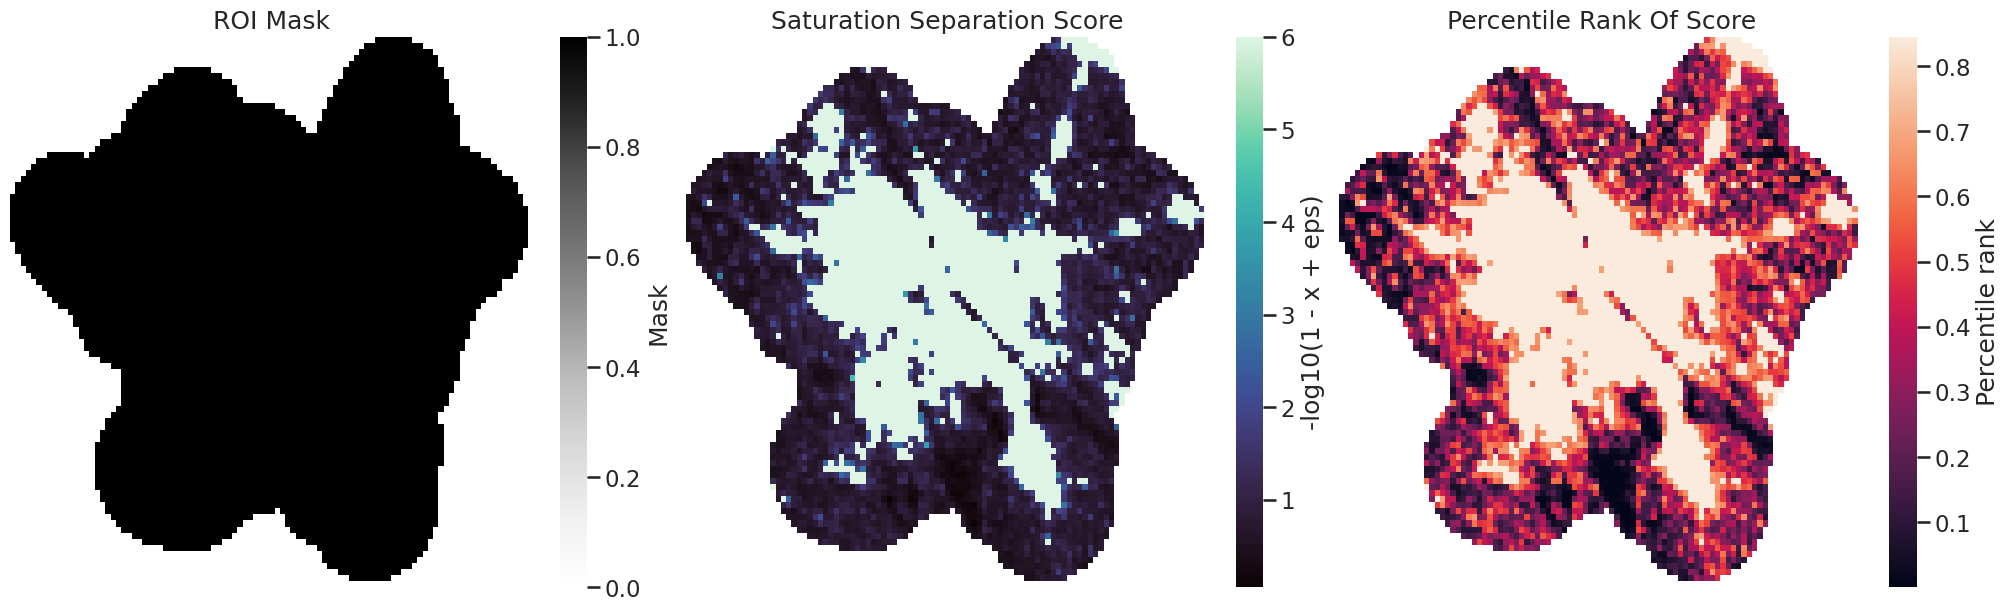

In [90]:
score_lo, score_hi = robust_limits(score_values, 0.000001, 0.999999)
rank_lo, rank_hi = robust_limits(score_rank_map[valid_mask], 0.000001, 0.999999)

fig, axes = plt.subplots(1, 3, figsize=(20, 6), constrained_layout=True)
draw_heatmap(axes[0], roi_mask.astype(float), roi_mask == 1, sns.color_palette('Greys', as_cmap=True), 'ROI Mask', vmin=0, vmax=1, cbar_label='Mask')
draw_heatmap(axes[1], score_map, valid_mask, sns.color_palette('mako', as_cmap=True), 'Saturation Separation Score', vmin=score_lo, vmax=score_hi, cbar_label='-log10(1 - x + eps)')
draw_heatmap(axes[2], score_rank_map, valid_mask, sns.color_palette('rocket', as_cmap=True), 'Percentile Rank Of Score', vmin=rank_lo, vmax=rank_hi, cbar_label='Percentile rank')
plt.show()

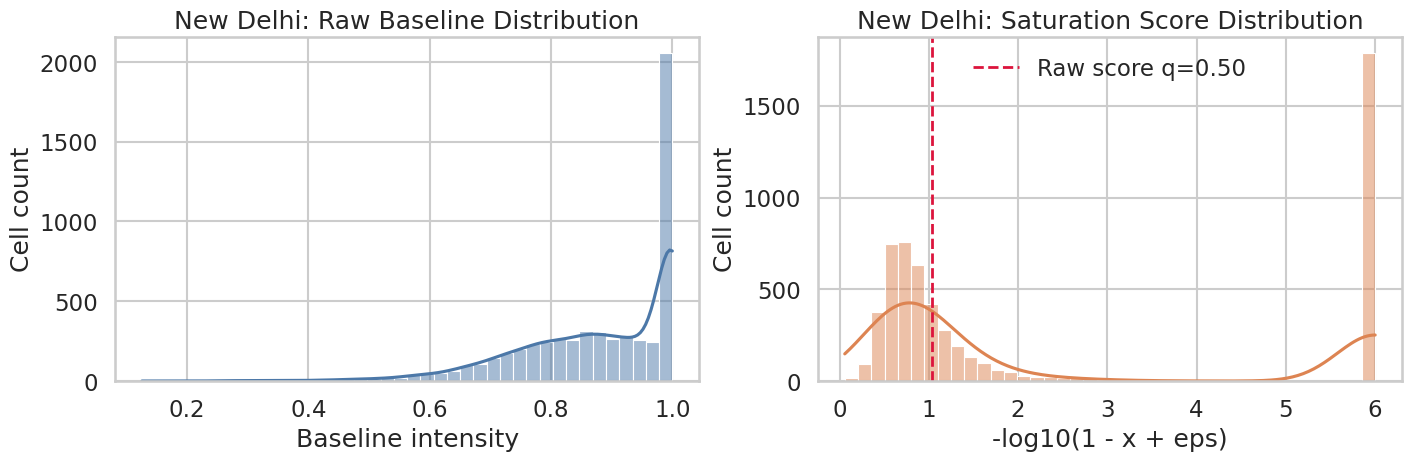

In [83]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), constrained_layout=True)
sns.histplot(valid_values, bins=40, kde=True, color='#4c78a8', ax=axes[0])
axes[0].set_title(f'{SELECTED_CITY}: Raw Baseline Distribution')
axes[0].set_xlabel('Baseline intensity')
axes[0].set_ylabel('Cell count')

sns.histplot(score_values, bins=40, kde=True, color='#dd8452', ax=axes[1])
axes[1].set_title(f'{SELECTED_CITY}: Saturation Score Distribution')
axes[1].set_xlabel('-log10(1 - x + eps)')
axes[1].set_ylabel('Cell count')
axes[1].axvline(np.quantile(score_values, HOTSPOT_QUANTILE), color='crimson', linestyle='--', linewidth=2, label=f'Raw score q={HOTSPOT_QUANTILE:.2f}')
axes[1].legend()
plt.show()

In [84]:
hotspots = build_hotspot_clusters(
    score_map=score_map,
    valid_mask=valid_mask,
    transform=transform,
    quantile=HOTSPOT_QUANTILE,
    n_clusters=N_CLUSTERS,
    random_state=RANDOM_STATE,
)

candidate_count = int(hotspots['candidate_mask'].sum())
print(f"Hotspot threshold on local saturation score: {hotspots['threshold']:.4f}")
print(f'Candidate hotspot cells: {candidate_count}')
print(f'Fitted clusters: {len(hotspots["summary"])}')
display(hotspots['summary'].round(3))

Hotspot threshold on local saturation score: 1.3090
Candidate hotspot cells: 2886
Fitted clusters: 986


,cluster_id,pixel_count,mean_score,max_score,mean_local_score,center_row,center_col,center_x,center_y
0,755,7,6.000,6.000,6.000,61.857,39.429,7131832.875,3461690.705
1,205,6,6.000,6.000,6.000,49.167,53.833,7146237.637,3474381.181
2,234,6,6.000,6.000,6.000,35.500,49.000,7141404.304,3488047.848
3,150,5,6.000,6.000,6.000,58.400,40.200,7132604.304,3465147.848
4,387,5,6.000,6.000,6.000,63.800,40.400,7132804.304,3459747.848
...,...,...,...,...,...,...,...,...,...
981,317,1,6.000,6.000,1.379,11.000,65.000,7157404.304,3512547.848
982,847,2,0.963,1.141,1.372,44.500,72.000,7164404.304,3479047.848
983,398,2,2.586,2.782,1.362,38.500,81.000,7173404.304,3485047.848
984,501,1,1.702,1.702,1.334,11.000,72.000,7164404.304,3512547.848


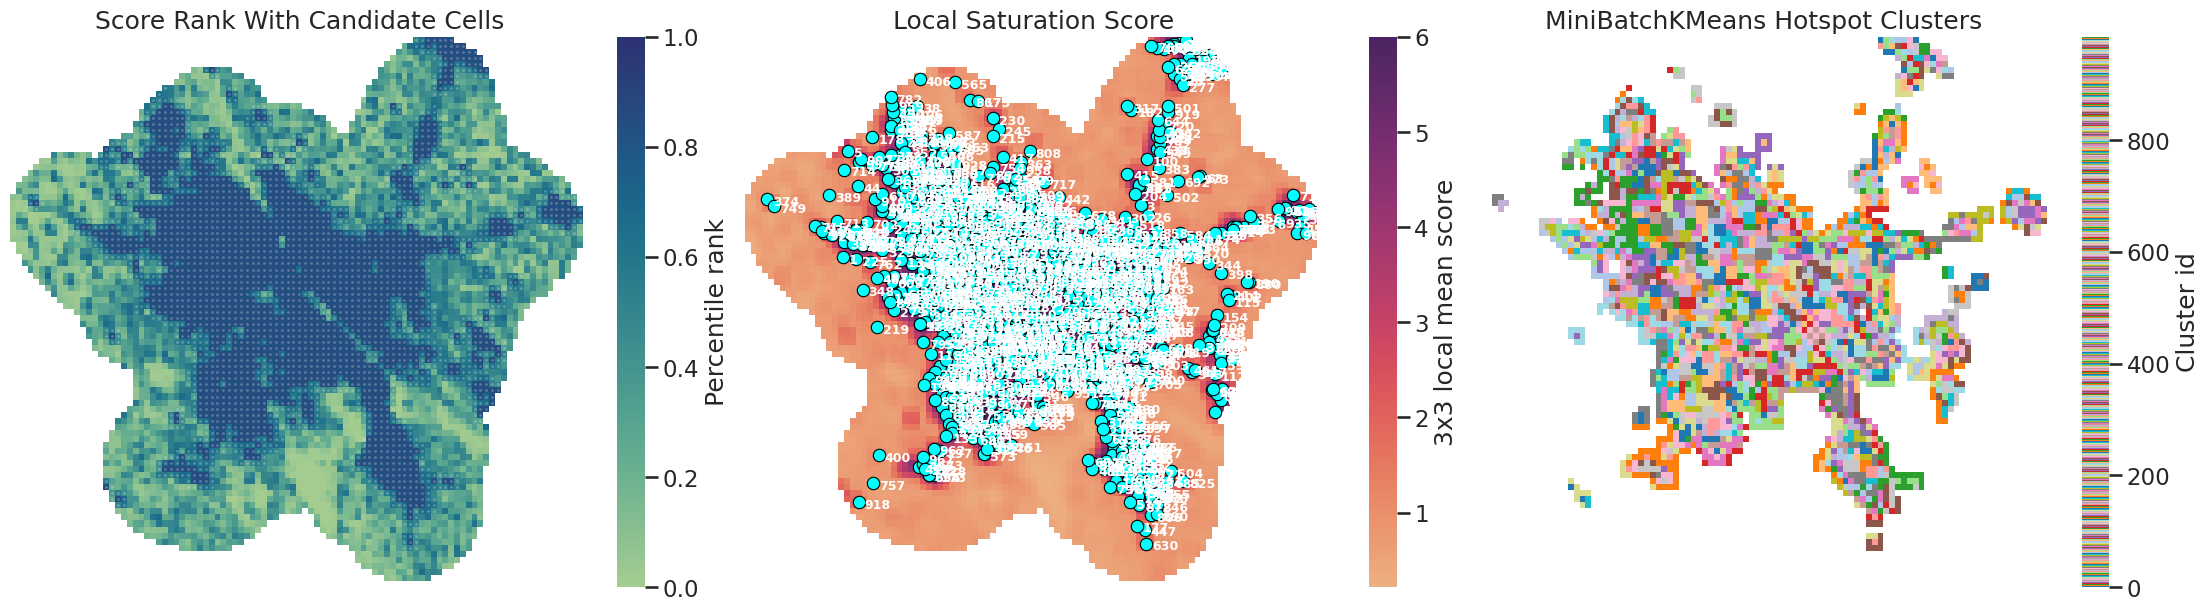

In [91]:
candidate_mask = hotspots['candidate_mask']
cluster_grid = hotspots['cluster_grid']
summary = hotspots['summary']
n_clusters = len(summary)
cluster_display = np.where(cluster_grid >= 0, cluster_grid, np.nan)
cluster_cmap = colors.ListedColormap(sns.color_palette('tab20', n_colors=max(n_clusters, 1)))

fig, axes = plt.subplots(1, 3, figsize=(22, 6), constrained_layout=True)
draw_heatmap(axes[0], score_rank_map, valid_mask, sns.color_palette('crest', as_cmap=True), 'Score Rank With Candidate Cells', vmin=0, vmax=1, cbar_label='Percentile rank')
cand_rows, cand_cols = np.where(candidate_mask)
axes[0].scatter(cand_cols + 0.5, cand_rows + 0.5, s=4, c='white', alpha=0.25, linewidths=0)

draw_heatmap(axes[1], hotspots['local_score'], valid_mask, sns.color_palette('flare', as_cmap=True), 'Local Saturation Score', cbar_label='3x3 local mean score')
for row in summary.itertuples(index=False):
    axes[1].scatter(row.center_col + 0.5, row.center_row + 0.5, s=80, color='cyan', edgecolor='black', linewidth=0.8)
    axes[1].text(row.center_col + 1.5, row.center_row + 1.5, str(int(row.cluster_id)), color='white', fontsize=9, weight='bold')

draw_heatmap(axes[2], cluster_display, cluster_grid >= 0, cluster_cmap, 'MiniBatchKMeans Hotspot Clusters', vmin=0, vmax=max(n_clusters - 1, 0), cbar_label='Cluster id')
legend_handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=cluster_cmap(i), markersize=8, label=f'Cluster {i}')
    for i in range(n_clusters)
]
# axes[2].legend(handles=legend_handles, loc='upper right', frameon=True, fontsize=8, ncol=2)
plt.show()